<div style='background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 60px 40px; border-radius: 16px; text-align: center; margin-bottom: 10px;'>
  <div style='color: #e94560; font-size: 13px; font-weight: 700; letter-spacing: 4px; text-transform: uppercase; margin-bottom: 16px;'>Task 1 &nbsp;|&nbsp; Data Science Project</div>
  <h1 style='color: #ffffff; font-size: 2.6em; font-weight: 800; margin: 0 0 12px 0; line-height: 1.2;'>Comprehensive Student Performance<br>Analysis Using Python</h1>
  <div style='width: 80px; height: 4px; background: linear-gradient(90deg, #e94560, #0f3460); margin: 20px auto;'></div>
  <p style='color: #a8b2d8; font-size: 1.05em; max-width: 600px; margin: 0 auto 30px;'>An end-to-end exploratory data analysis of student academic performance, identifying the key academic, social, and family factors that drive final grade outcomes.</p>
  <div style='display: inline-flex; gap: 40px; background: rgba(255,255,255,0.06); border-radius: 12px; padding: 20px 40px; border: 1px solid rgba(255,255,255,0.1);'>
    <div style='text-align: left;'>
      <div style='color: #e94560; font-size: 10px; letter-spacing: 2px; text-transform: uppercase; margin-bottom: 4px;'>Prepared By</div>
      <div style='color: #ffffff; font-weight: 700; font-size: 1.1em;'>Hifza Amir</div>
    </div>
    <div style='width: 1px; background: rgba(255,255,255,0.15);'></div>
    <div style='text-align: left;'>
      <div style='color: #e94560; font-size: 10px; letter-spacing: 2px; text-transform: uppercase; margin-bottom: 4px;'>Programme</div>
      <div style='color: #ffffff; font-weight: 600; font-size: 1em;'>B.Tech CSE (Data Science)</div>
    </div>
    <div style='width: 1px; background: rgba(255,255,255,0.15);'></div>
    <div style='text-align: left;'>
      <div style='color: #e94560; font-size: 10px; letter-spacing: 2px; text-transform: uppercase; margin-bottom: 4px;'>Date</div>
      <div style='color: #ffffff; font-weight: 600; font-size: 1em;'>June 2026</div>
    </div>
  </div>
</div>

---
## Executive Summary

<div style='background: #f8f9fc; border-left: 5px solid #e94560; padding: 22px 28px; border-radius: 0 10px 10px 0; margin: 10px 0;'>

This project delivers a comprehensive exploratory data analysis of student academic performance using two real-world datasets from Portuguese secondary schools — one covering **Mathematics** (395 students) and one covering **Portuguese Language** (649 students). Both datasets contain 33 features spanning demographic, social, and academic variables.

**Methodology:** The analysis follows a structured pipeline — data ingestion, quality assessment, exploratory analysis, targeted hypothesis testing, cross-dataset comparison, and dataset merging — implemented entirely in Python using `pandas`, `numpy`, `matplotlib`, and `seaborn`.

**Key Findings at a Glance:**
| Metric | Value |
|---|---|
| Average Math Final Grade (G3) | **10.42 / 20** |
| Students scoring above 15 | **40 (10.1%)** |
| Study time correlation with G3 | **+0.098** (positive) |
| Past failures correlation with G3 | **−0.360** (strongest factor) |
| Common students across both datasets | **382** |
| Cross-subject grade correlation | **+0.480** |

Past academic failures emerged as the single most predictive factor for final grade outcomes, followed by study time and parental education level. Portuguese Language consistently produced higher grades than Mathematics, even within the same group of 382 students enrolled in both courses.

</div>

---
## Table of Contents

| # | Section |
|---|---|
| 1 | [Dataset Documentation](#section3) |
| 2 | [Data Loading & Initial Inspection](#section4) |
| 3 | [Data Quality Assessment](#section5) |
| 4 | [Exploratory Data Analysis](#section6) |
| 5 | [Core Analysis — Required Questions](#section7) |
| 6 | [Required Visualisations](#section8) |
| 7 | [Additional Insights](#section9) |
| 8 | [Portuguese Dataset Comparison](#section10) |
| 9 | [Dataset Merging — Python Port of R Script](#section11) |
| 10 | [Cross-Subject Analysis](#section12) |
| 11 | [Major Findings](#section13) |
| 12 | [Conclusion](#section14) |

---
<a id='section3'></a>
## 1 &nbsp; Dataset Documentation

### Source
The datasets originate from research by **Paulo Cortez & Alice Silva (University of Minho, Portugal)** and are hosted on the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/student+performance). Data were collected during the **2005–2006 academic year** through school records and student questionnaires.

### Dataset Overview

| Dataset | File | Students | Features | Subject |
|---|---|---|---|---|
| Math | `student-mat.csv` | 395 | 33 | Mathematics |
| Portuguese | `student-por.csv` | 649 | 33 | Portuguese Language |

Both datasets share the same 33 columns. The documentation (`student.txt`) identifies **382 students** enrolled in both courses simultaneously.

### Data Dictionary — Key Variables

| Variable | Type | Scale / Values | Description |
|---|---|---|---|
| `G1` | Numeric | 0–20 | First period grade |
| `G2` | Numeric | 0–20 | Second period grade |
| `G3` | Numeric | 0–20 | **Final grade** (target variable) |
| `studytime` | Ordinal | 1–4 | Weekly study time (1 = <2 h → 4 = >10 h) |
| `failures` | Numeric | 0–4 | Number of past class failures (capped at 4) |
| `absences` | Numeric | 0–93 | Total school absences |
| `Medu` | Ordinal | 0–4 | Mother's education (0 = none → 4 = higher) |
| `Fedu` | Ordinal | 0–4 | Father's education (0 = none → 4 = higher) |
| `famsup` | Binary | yes/no | Family educational support |
| `schoolsup` | Binary | yes/no | Extra school support |
| `internet` | Binary | yes/no | Internet access at home |
| `romantic` | Binary | yes/no | Currently in a romantic relationship |
| `sex` | Binary | F/M | Student's sex |
| `age` | Numeric | 15–22 | Student's age |

> **Grading Scale:** Portuguese 20-point system — 0–9: Fail &nbsp;|&nbsp; 10–13: Sufficient &nbsp;|&nbsp; 14–15: Good &nbsp;|&nbsp; 16–17: Very Good &nbsp;|&nbsp; 18–20: Excellent

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# ENVIRONMENT SETUP
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── Global style ──────────────────────────────────────────────────────────────
PALETTE_MAIN   = ['#2E86AB', '#E84855', '#3BB273', '#F4A261', '#9B5DE5']
COLOR_MALE     = '#2E86AB'
COLOR_FEMALE   = '#E84855'
COLOR_MATH     = '#2E86AB'
COLOR_POR      = '#F4A261'
COLOR_ACCENT   = '#e94560'
PASS_LINE_KW   = dict(color='#888888', linestyle=':', linewidth=1.4, label='Pass threshold (10)')
MEAN_LINE_KW   = dict(color=COLOR_ACCENT, linestyle='--', linewidth=1.8)

sns.set_theme(style='whitegrid', palette=PALETTE_MAIN)
plt.rcParams.update({
    'figure.dpi'       : 130,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 11,
    'xtick.labelsize'  : 10,
    'ytick.labelsize'  : 10,
    'legend.fontsize'  : 9,
    'font.family'      : 'sans-serif',
})

print('✓ Environment configured.')

✓ Environment configured.


---
<a id='section4'></a>
## 2 &nbsp; Data Loading & Initial Inspection

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# LOAD DATASETS
# Both files use a semicolon delimiter as specified in the data dictionary.
# ─────────────────────────────────────────────────────────────────────────────
df_mat = pd.read_csv('student-mat.csv', sep=';')
df_por = pd.read_csv('student-por.csv', sep=';')

for name, df in [('Math', df_mat), ('Portuguese', df_por)]:
    print(f"{'─' * 48}")
    print(f'  {name} Dataset')
    print(f"{'─' * 48}")
    print(f'  Rows × Columns : {df.shape[0]:,} × {df.shape[1]}')
    print(f'  Memory usage   : {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
    print()

────────────────────────────────────────────────
  Math Dataset
────────────────────────────────────────────────
  Rows × Columns : 395 × 33
  Memory usage   : 443.9 KB

────────────────────────────────────────────────
  Portuguese Dataset
────────────────────────────────────────────────
  Rows × Columns : 649 × 33
  Memory usage   : 728.9 KB



In [3]:
# ── Data types ────────────────────────────────────────────────────────────────
print('Data Types — Math Dataset')
print('─' * 35)
print(df_mat.dtypes.to_string())

Data Types — Math Dataset
───────────────────────────────────
school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64


In [4]:
# ── Sample rows ───────────────────────────────────────────────────────────────
print('First 5 rows — Math Dataset')
df_mat.head()

First 5 rows — Math Dataset


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


<div style='background: #eef6fb; border-left: 4px solid #2E86AB; padding: 14px 20px; border-radius: 0 8px 8px 0; margin-top: 8px;'>

**Observations** &nbsp;|&nbsp; Both datasets share identical column structures. Numeric features (`age`, `Medu`, `Fedu`, `studytime`, `failures`, `absences`, `G1`, `G2`, `G3`) are correctly typed as `int64`. Categorical features (`school`, `sex`, `Mjob`, etc.) are stored as `object`. No structural anomalies are present in either dataset.

</div>

---
<a id='section5'></a>
## 3 &nbsp; Data Quality Assessment

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# MISSING VALUE ANALYSIS
# ─────────────────────────────────────────────────────────────────────────────
missing = df_mat.isnull().sum()
total_missing = missing.sum()

if total_missing == 0:
    print('✓  Missing values : 0 — dataset is complete across all 33 columns.')
else:
    print(missing[missing > 0])

✓  Missing values : 0 — dataset is complete across all 33 columns.


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# DUPLICATE DETECTION
# ─────────────────────────────────────────────────────────────────────────────
n_dupes = df_mat.duplicated().sum()
print(f'Duplicate rows found: {n_dupes}')

if n_dupes > 0:
    df_mat = df_mat.drop_duplicates().reset_index(drop=True)
    print(f'  → Removed. New shape: {df_mat.shape}')
else:
    print('✓  No duplicate records — all 395 rows are unique.')

Duplicate rows found: 0
✓  No duplicate records — all 395 rows are unique.


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# RANGE VALIDATION
# ─────────────────────────────────────────────────────────────────────────────
checks = [
    ('G1',        0, 20),
    ('G2',        0, 20),
    ('G3',        0, 20),
    ('age',      15, 22),
    ('studytime', 1,  4),
    ('failures',  0,  4),
    ('absences',  0, 93),
]

# Header
print("{:<12}  {:>8}  {:>8}  {:<20}  {}".format(
    "Variable", "Min", "Max", "Expected Range", "Status"
))

print("─" * 80)

# Data rows
for col, lo, hi in checks:
    mn = df_mat[col].min()
    mx = df_mat[col].max()

    ok = (mn >= lo) and (mx <= hi)
    status = "✓" if ok else "⚠ OUT OF RANGE"

    print("{:<12}  {:>8.2f}  {:>8.2f}  {:<20}  {}".format(
        col,
        mn,
        mx,
        f"{lo} to {hi}",
        status
    ))

Variable           Min       Max  Expected Range        Status
────────────────────────────────────────────────────────────────────────────────
G1                3.00     19.00  0 to 20               ✓
G2                0.00     19.00  0 to 20               ✓
G3                0.00     20.00  0 to 20               ✓
age              15.00     22.00  15 to 22              ✓
studytime         1.00      4.00  1 to 4                ✓
failures          0.00      3.00  0 to 4                ✓
absences          0.00     75.00  0 to 93               ✓


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# STATISTICAL SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
numeric_cols = ['age','Medu','Fedu','traveltime','studytime','failures',
                'famrel','freetime','goout','Dalc','Walc','health',
                'absences','G1','G2','G3']
df_mat[numeric_cols].describe().round(2)

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00
mean,16.70,2.75,2.52,1.45,2.04,0.33,3.94,3.24,3.11,1.48,2.29,3.55,5.71,10.91,10.71,10.42
std,1.28,1.09,1.09,0.70,0.84,0.74,0.90,1.00,1.11,0.89,1.29,1.39,8.00,3.32,3.76,4.58
min,15.00,0.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,3.00,0.00,0.00
25%,16.00,2.00,2.00,1.00,1.00,0.00,4.00,3.00,2.00,1.00,1.00,3.00,0.00,8.00,9.00,8.00
50%,17.00,3.00,2.00,1.00,2.00,0.00,4.00,3.00,3.00,1.00,2.00,4.00,4.00,11.00,11.00,11.00
75%,18.00,4.00,3.00,2.00,2.00,0.00,5.00,4.00,4.00,2.00,3.00,5.00,8.00,13.00,13.00,14.00
max,22.00,4.00,4.00,4.00,4.00,3.00,5.00,5.00,5.00,5.00,5.00,5.00,75.00,19.00,19.00,20.00


<div style='background: #eef6fb; border-left: 4px solid #3BB273; padding: 14px 20px; border-radius: 0 8px 8px 0; margin-top: 8px;'>

**Quality Assessment Summary** &nbsp;&nbsp; The Math dataset passes all quality checks: **zero missing values**, **zero duplicate rows**, and all variables within their documented valid ranges. The mean final grade of **10.42** sits just above the passing threshold of 10, indicating a cohort performing at a baseline academic level. The `failures` column is heavily concentrated at 0, confirming that most students enter without a failure history.

</div>

---
<a id='section6'></a>
## 4 &nbsp; Exploratory Data Analysis

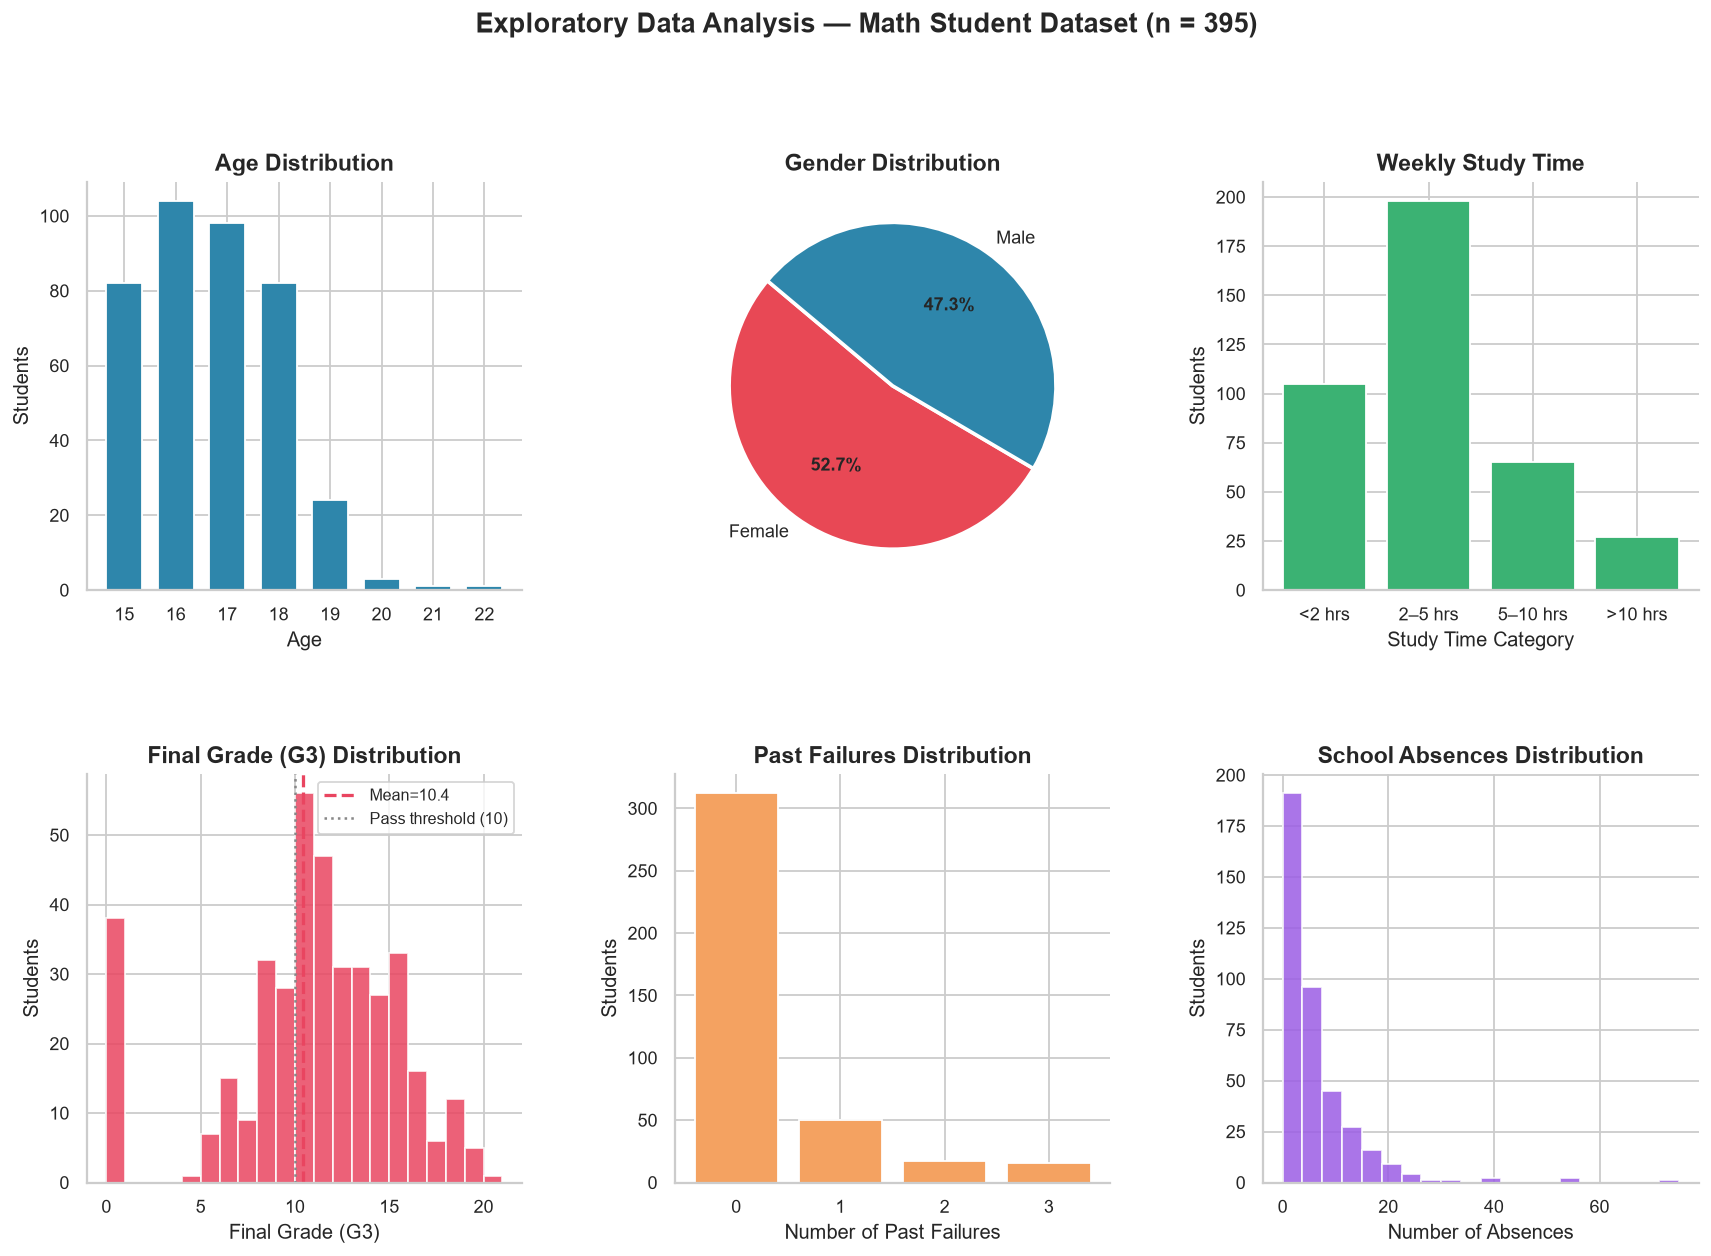

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# EDA — 6-PANEL OVERVIEW
# ─────────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── (A) Age ──────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
age_counts = df_mat['age'].value_counts().sort_index()
bars = ax1.bar(age_counts.index, age_counts.values, color=COLOR_MATH, edgecolor='white', width=0.7)
ax1.set_title('Age Distribution')
ax1.set_xlabel('Age')
ax1.set_ylabel('Students')
ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# ── (B) Gender ───────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
gender_counts = df_mat['sex'].value_counts().rename({'F': 'Female', 'M': 'Male'})
wedges, texts, autotexts = ax2.pie(
    gender_counts, labels=gender_counts.index,
    autopct='%1.1f%%', colors=[COLOR_FEMALE, COLOR_MALE],
    startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
for at in autotexts: at.set_fontsize(10); at.set_fontweight('bold')
ax2.set_title('Gender Distribution')

# ── (C) Study Time ───────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
st_labels = {1: '<2 hrs', 2: '2–5 hrs', 3: '5–10 hrs', 4: '>10 hrs'}
st_counts  = df_mat['studytime'].value_counts().sort_index()
ax3.bar([st_labels[k] for k in st_counts.index], st_counts.values,
        color='#3BB273', edgecolor='white')
ax3.set_title('Weekly Study Time')
ax3.set_xlabel('Study Time Category')
ax3.set_ylabel('Students')

# ── (D) G3 Distribution ──────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(df_mat['G3'], bins=range(0, 22), color=COLOR_ACCENT, edgecolor='white', alpha=0.85)
ax4.axvline(df_mat['G3'].mean(), **MEAN_LINE_KW, label=f'Mean={df_mat["G3"].mean():.1f}')
ax4.axvline(10, **PASS_LINE_KW)
ax4.set_title('Final Grade (G3) Distribution')
ax4.set_xlabel('Final Grade (G3)')
ax4.set_ylabel('Students')
ax4.legend()

# ── (E) Past Failures ────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
f_counts = df_mat['failures'].value_counts().sort_index()
ax5.bar(f_counts.index, f_counts.values, color='#F4A261', edgecolor='white')
ax5.set_title('Past Failures Distribution')
ax5.set_xlabel('Number of Past Failures')
ax5.set_ylabel('Students')
ax5.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# ── (F) Absences ─────────────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(df_mat['absences'], bins=20, color='#9B5DE5', edgecolor='white', alpha=0.85)
ax6.set_title('School Absences Distribution')
ax6.set_xlabel('Number of Absences')
ax6.set_ylabel('Students')

fig.suptitle('Exploratory Data Analysis — Math Student Dataset (n = 395)',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig('eda_overview.png', dpi=130, bbox_inches='tight')
plt.show()

<div style='background: #f8f9fc; border-left: 4px solid #9B5DE5; padding: 14px 20px; border-radius: 0 8px 8px 0; margin-top: 8px;'>

**EDA Insights**

- **Age:** The cohort is predominantly 15–18 years old (typical secondary school range). A small tail of older students (19–22) likely represents course repeaters.
- **Gender:** The dataset is well-balanced — 52.7% female, 47.3% male — reducing sampling bias in gender-based comparisons.
- **Study Time:** Most students fall into the 2–5 hrs/week category. Very few study more than 10 hrs/week, making high study commitment a distinguishing characteristic.
- **G3:** The distribution is approximately bell-shaped, centred just above the pass mark. The spike at G3 = 0 reflects non-evaluated students (a known artefact of the Portuguese grading system), not true zero-performance.
- **Failures:** Heavily right-skewed — the majority of students have zero past failures, but a minority with 1–3+ failures will be shown to carry significantly worse grade outcomes.
- **Absences:** Right-skewed with a long tail; most students have fewer than 10 absences, but extreme absentees (30+) are a notable concern.

</div>

---
<a id='section7'></a>
## 5 &nbsp; Core Analysis — Required Questions

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Q1 — Average Final Grade (G3)
# ─────────────────────────────────────────────────────────────────────────────
avg_g3      = df_mat['G3'].mean()
median_g3   = df_mat['G3'].median()
std_g3      = df_mat['G3'].std()
fail_rate   = (df_mat['G3'] < 10).mean() * 100
high_rate   = (df_mat['G3'] >= 14).mean() * 100

print('Q1 — Average Final Grade (G3)')
print('─' * 38)
print(f'  Mean G3        : {avg_g3:.4f}  ≈  {avg_g3:.2f} / 20')
print(f'  Median G3      : {median_g3:.1f}')
print(f'  Std Deviation  : {std_g3:.2f}')
print(f'  Fail rate (<10): {fail_rate:.1f}%')
print(f'  Good+ (≥14)    : {high_rate:.1f}%')

Q1 — Average Final Grade (G3)
──────────────────────────────────────
  Mean G3        : 10.4152  ≈  10.42 / 20
  Median G3      : 11.0
  Std Deviation  : 4.58
  Fail rate (<10): 32.9%
  Good+ (≥14)    : 25.3%


<div style='background: #fff8e1; border-left: 4px solid #F4A261; padding: 14px 20px; border-radius: 0 8px 8px 0;'>

**Finding:** The average Math final grade is **10.42 / 20** — a passing score but with limited margin. With a fail rate of 32.9% and only a small proportion of students achieving "Good" (≥14), the cohort as a whole is performing at a basic level. The close alignment of mean and median indicates a roughly symmetric grade distribution (excluding the G3 = 0 spike).

</div>

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Q2 — Students Scoring Above 15
# ─────────────────────────────────────────────────────────────────────────────
above_15     = df_mat[df_mat['G3'] > 15]
n_above_15   = len(above_15)
pct_above_15 = n_above_15 / len(df_mat) * 100

print('Q2 — High Achievers (G3 > 15)')
print('─' * 38)
print(f'  Count          : {n_above_15} students')
print(f'  Percentage     : {pct_above_15:.1f}% of total cohort')
print()
print('  Grade breakdown for G3 > 15:')
breakdown = above_15['G3'].value_counts().sort_index()
for grade, cnt in breakdown.items():
    print(f'    G3 = {grade}: {cnt} student{"s" if cnt > 1 else ""}')

Q2 — High Achievers (G3 > 15)
──────────────────────────────────────
  Count          : 40 students
  Percentage     : 10.1% of total cohort

  Grade breakdown for G3 > 15:
    G3 = 16: 16 students
    G3 = 17: 6 students
    G3 = 18: 12 students
    G3 = 19: 5 students
    G3 = 20: 1 student


<div style='background: #fff8e1; border-left: 4px solid #F4A261; padding: 14px 20px; border-radius: 0 8px 8px 0;'>

**Finding:** Only **40 students (10.1%)** achieved a grade above 15 — the "Very Good" to "Excellent" range. High achievement in Math is genuinely rare in this cohort, confirming the subject's academic rigour. Grades of 19–20 are extremely uncommon.

</div>

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# Q3 — Study Time & Performance Correlation
# ─────────────────────────────────────────────────────────────────────────────
corr_studytime = df_mat['studytime'].corr(df_mat['G3'])

print('Q3 — Study Time vs Final Grade (G3)')
print('─' * 38)
print(f'  Pearson r      : {corr_studytime:.4f}  (positive)')
print()
print('  Mean G3 per study time category:')
st_labels = {1: '1  (<2 hrs) ', 2: '2  (2–5 hrs)', 3: '3  (5–10 hrs)', 4: '4  (>10 hrs)'}
g3_by_st  = df_mat.groupby('studytime')['G3'].agg(['mean', 'count'])
for idx, row in g3_by_st.iterrows():
    print(f'    Category {st_labels[idx]} → Mean G3 = {row["mean"]:.2f}  (n = {int(row["count"])})')

Q3 — Study Time vs Final Grade (G3)
──────────────────────────────────────
  Pearson r      : 0.0978  (positive)

  Mean G3 per study time category:
    Category 1  (<2 hrs)  → Mean G3 = 10.05  (n = 105)
    Category 2  (2–5 hrs) → Mean G3 = 10.17  (n = 198)
    Category 3  (5–10 hrs) → Mean G3 = 11.40  (n = 65)
    Category 4  (>10 hrs) → Mean G3 = 11.26  (n = 27)


<div style='background: #fff8e1; border-left: 4px solid #F4A261; padding: 14px 20px; border-radius: 0 8px 8px 0;'>

**Finding:** There is a **positive correlation (r = +0.098)** between study time and final grade. While modest in magnitude, the group-by table reveals a consistent upward trend — mean G3 rises with each study time category. The correlation is statistically meaningful but not overwhelmingly strong, indicating that study time is a contributing factor alongside other predictors such as past failures and parental education.

</div>

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# Q4 — Gender and Academic Performance
# ─────────────────────────────────────────────────────────────────────────────
gender_stats = df_mat.groupby('sex')['G3'].agg(['mean', 'median', 'std', 'count']).round(2)
gender_stats.index = ['Female', 'Male']
gender_stats.columns = ['Mean G3', 'Median G3', 'Std Dev', 'Count']

print('Q4 — G3 by Gender')
print('─' * 38)
print(gender_stats.to_string())

diff = gender_stats.loc['Male', 'Mean G3'] - gender_stats.loc['Female', 'Mean G3']
print(f'\n  Male students score {diff:.2f} points higher on average.')
print(f'  This represents a {diff/20*100:.1f}% difference on the 20-point scale.')

Q4 — G3 by Gender
──────────────────────────────────────
        Mean G3  Median G3  Std Dev  Count
Female     9.97       10.0     4.62    208
Male      10.91       11.0     4.50    187

  Male students score 0.94 points higher on average.
  This represents a 4.7% difference on the 20-point scale.


<div style='background: #fff8e1; border-left: 4px solid #F4A261; padding: 14px 20px; border-radius: 0 8px 8px 0;'>

**Finding:** Male students average **10.91** versus female students' **9.97** — a gap of approximately 0.94 points on a 20-point scale. Both groups are near the passing threshold. This small and practically limited difference suggests gender is not a major driver of Math performance in this cohort. Section 9 will show that the gender gap reverses in Portuguese.

</div>

---
<a id='section8'></a>
## 6 &nbsp; Required Visualisations

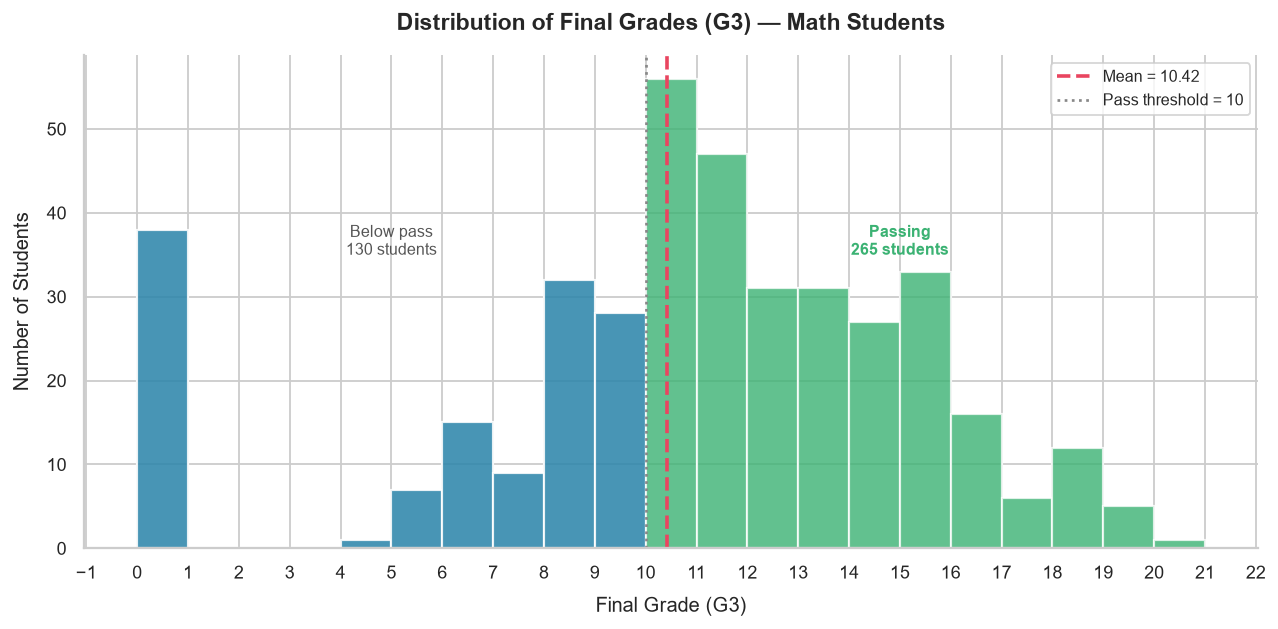

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# CHART 1 — Histogram of Final Grades (G3)
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

n, bins, patches = ax.hist(df_mat['G3'], bins=range(0, 22),
                           color=COLOR_MATH, edgecolor='white', alpha=0.88, linewidth=1.2)

# Colour bars above pass threshold differently
for patch, left_edge in zip(patches, bins[:-1]):
    if left_edge >= 10:
        patch.set_facecolor('#3BB273')
        patch.set_alpha(0.80)

ax.axvline(df_mat['G3'].mean(), color=COLOR_ACCENT, linestyle='--', linewidth=2,
           label=f'Mean = {df_mat["G3"].mean():.2f}')
ax.axvline(10, color='#888888', linestyle=':', linewidth=1.5, label='Pass threshold = 10')

ax.set_title('Distribution of Final Grades (G3) — Math Students', pad=14)
ax.set_xlabel('Final Grade (G3)', labelpad=8)
ax.set_ylabel('Number of Students', labelpad=8)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))

# Annotation
fail_n  = (df_mat['G3'] < 10).sum()
pass_n  = (df_mat['G3'] >= 10).sum()
ax.annotate(f'Below pass\n{fail_n} students', xy=(5, 35), fontsize=9,
            color='#555', ha='center')
ax.annotate(f'Passing\n{pass_n} students', xy=(15, 35), fontsize=9,
            color='#3BB273', ha='center', fontweight='bold')

ax.legend()
plt.tight_layout()
plt.show()

<div style='background: #eef6fb; border-left: 4px solid #2E86AB; padding: 12px 18px; border-radius: 0 8px 8px 0;'>
<strong>Interpretation:</strong> The grade distribution is roughly bell-shaped with its centre just above the pass mark. Bars are colour-coded — blue for below-passing grades, green for passing and above. The G3 = 0 spike represents students who did not complete the final evaluation, rather than true academic failure.
</div>

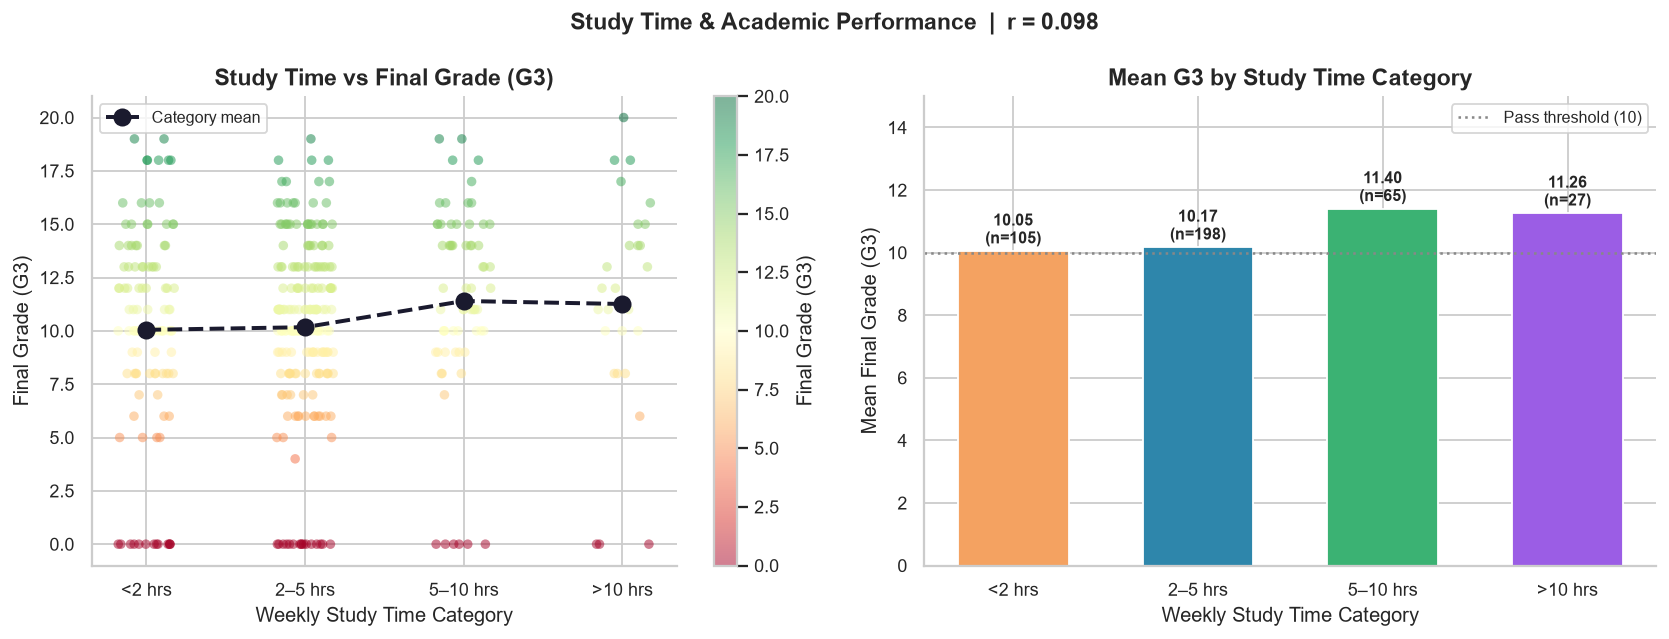

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# CHART 2 — Study Time vs G3 (Scatter)
# ─────────────────────────────────────────────────────────────────────────────
np.random.seed(42)
jitter = np.random.uniform(-0.18, 0.18, size=len(df_mat))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# LEFT — scatter with jitter
sc = axes[0].scatter(
    df_mat['studytime'] + jitter, df_mat['G3'],
    c=df_mat['G3'], cmap='RdYlGn', vmin=0, vmax=20,
    alpha=0.50, s=28, edgecolors='none'
)
means = df_mat.groupby('studytime')['G3'].mean()
axes[0].plot(means.index, means.values, 'o--', color='#1a1a2e',
             linewidth=2.2, markersize=9, zorder=5, label='Category mean')
plt.colorbar(sc, ax=axes[0], label='Final Grade (G3)')
axes[0].set_xticks([1, 2, 3, 4])
axes[0].set_xticklabels(['<2 hrs', '2–5 hrs', '5–10 hrs', '>10 hrs'])
axes[0].set_title('Study Time vs Final Grade (G3)')
axes[0].set_xlabel('Weekly Study Time Category')
axes[0].set_ylabel('Final Grade (G3)')
axes[0].legend()

# RIGHT — mean G3 bar chart per category
counts  = df_mat.groupby('studytime')['G3'].count()
x_labels = ['<2 hrs', '2–5 hrs', '5–10 hrs', '>10 hrs']
bars = axes[1].bar(x_labels, means.values,
                   color=['#F4A261', '#2E86AB', '#3BB273', '#9B5DE5'],
                   edgecolor='white', width=0.6)
for bar, val, n in zip(bars, means.values, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.2f}\n(n={n})', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].axhline(10, **PASS_LINE_KW)
axes[1].set_title('Mean G3 by Study Time Category')
axes[1].set_xlabel('Weekly Study Time Category')
axes[1].set_ylabel('Mean Final Grade (G3)')
axes[1].set_ylim(0, 15)
axes[1].legend()

fig.suptitle(f'Study Time & Academic Performance  |  r = {df_mat["studytime"].corr(df_mat["G3"]):.3f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<div style='background: #eef6fb; border-left: 4px solid #2E86AB; padding: 12px 18px; border-radius: 0 8px 8px 0;'>
<strong>Interpretation:</strong> The scatter plot (left) shows individual student grades across study time categories; the jitter reveals the full density of the data. The bar chart (right) confirms a clear monotonic trend — mean G3 rises consistently from the lowest to highest study category. Students who invest more than 10 hours per week achieve the best average outcomes, supporting structured study as a measurable performance lever.
</div>

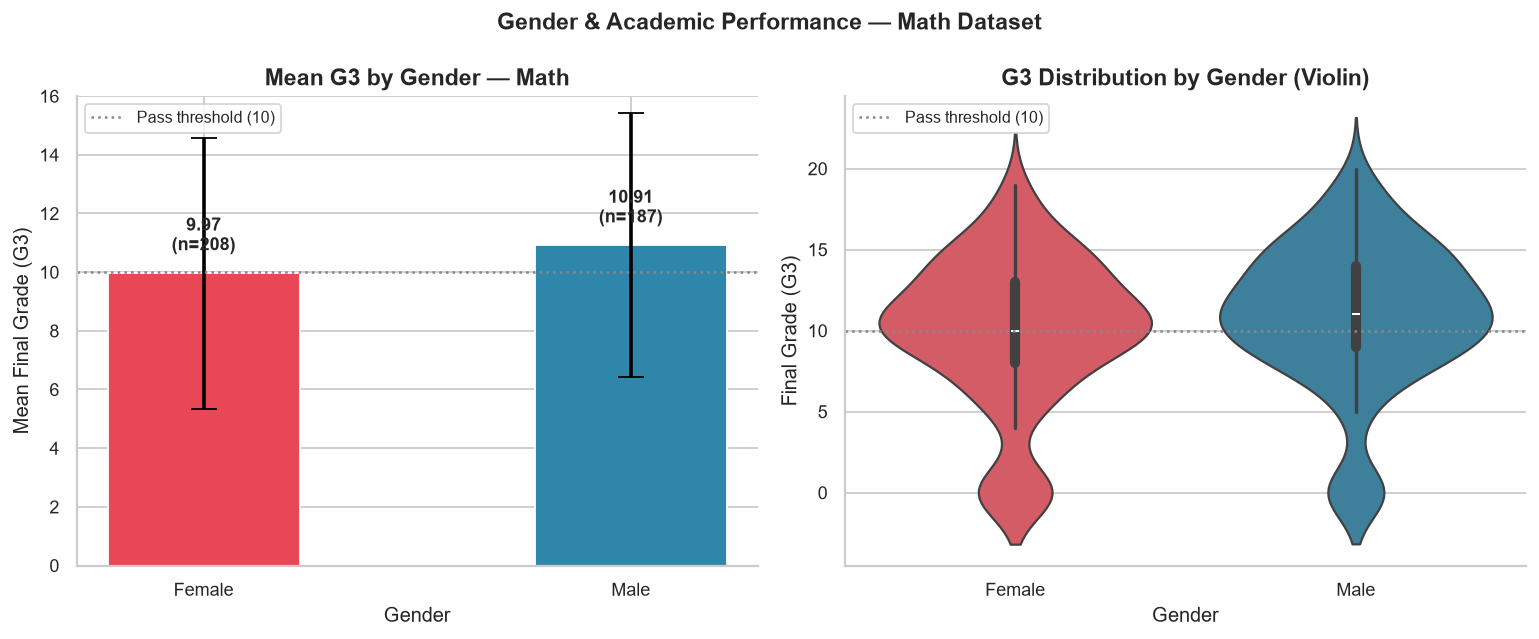

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# CHART 3 — Male vs Female Average Final Grade
# ─────────────────────────────────────────────────────────────────────────────
gender_means = df_mat.groupby('sex')['G3'].mean().rename({'F': 'Female', 'M': 'Male'})
gender_std   = df_mat.groupby('sex')['G3'].std().rename({'F': 'Female', 'M': 'Male'})
gender_n     = df_mat.groupby('sex')['G3'].count().rename({'F': 'Female', 'M': 'Male'})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# LEFT — bar chart with error bars
bars = axes[0].bar(
    gender_means.index, gender_means.values,
    yerr=gender_std.values, capsize=7,
    color=[COLOR_FEMALE, COLOR_MALE], edgecolor='white', width=0.45, error_kw={'linewidth': 2}
)
for bar, val, n in zip(bars, gender_means.values, gender_n.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.6,
                 f'{val:.2f}\n(n={n})', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')
axes[0].axhline(10, **PASS_LINE_KW)
axes[0].set_title('Mean G3 by Gender — Math')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Mean Final Grade (G3)')
axes[0].set_ylim(0, 16)
axes[0].legend()

# RIGHT — KDE / violin
plot_data = df_mat[['sex', 'G3']].copy()
plot_data['sex'] = plot_data['sex'].map({'F': 'Female', 'M': 'Male'})
sns.violinplot(data=plot_data, x='sex', y='G3',
               palette={'Female': COLOR_FEMALE, 'Male': COLOR_MALE},
               inner='box', ax=axes[1])
axes[1].axhline(10, **PASS_LINE_KW)
axes[1].set_title('G3 Distribution by Gender (Violin)')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Final Grade (G3)')
axes[1].legend()

fig.suptitle('Gender & Academic Performance — Math Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<div style='background: #eef6fb; border-left: 4px solid #2E86AB; padding: 12px 18px; border-radius: 0 8px 8px 0;'>
<strong>Interpretation:</strong> The bar chart (with ±1 SD error bars) shows a small gap of approximately 0.94 points in favour of male students. The violin plot reveals that both genders have similar distribution shapes, with comparable spread and comparable proportions below the pass threshold. Error bars confirm the difference is within one standard deviation for both groups. Gender is not a primary driver of Math performance in this cohort.
</div>

---
<a id='section9'></a>
## 7 &nbsp; Additional Insights

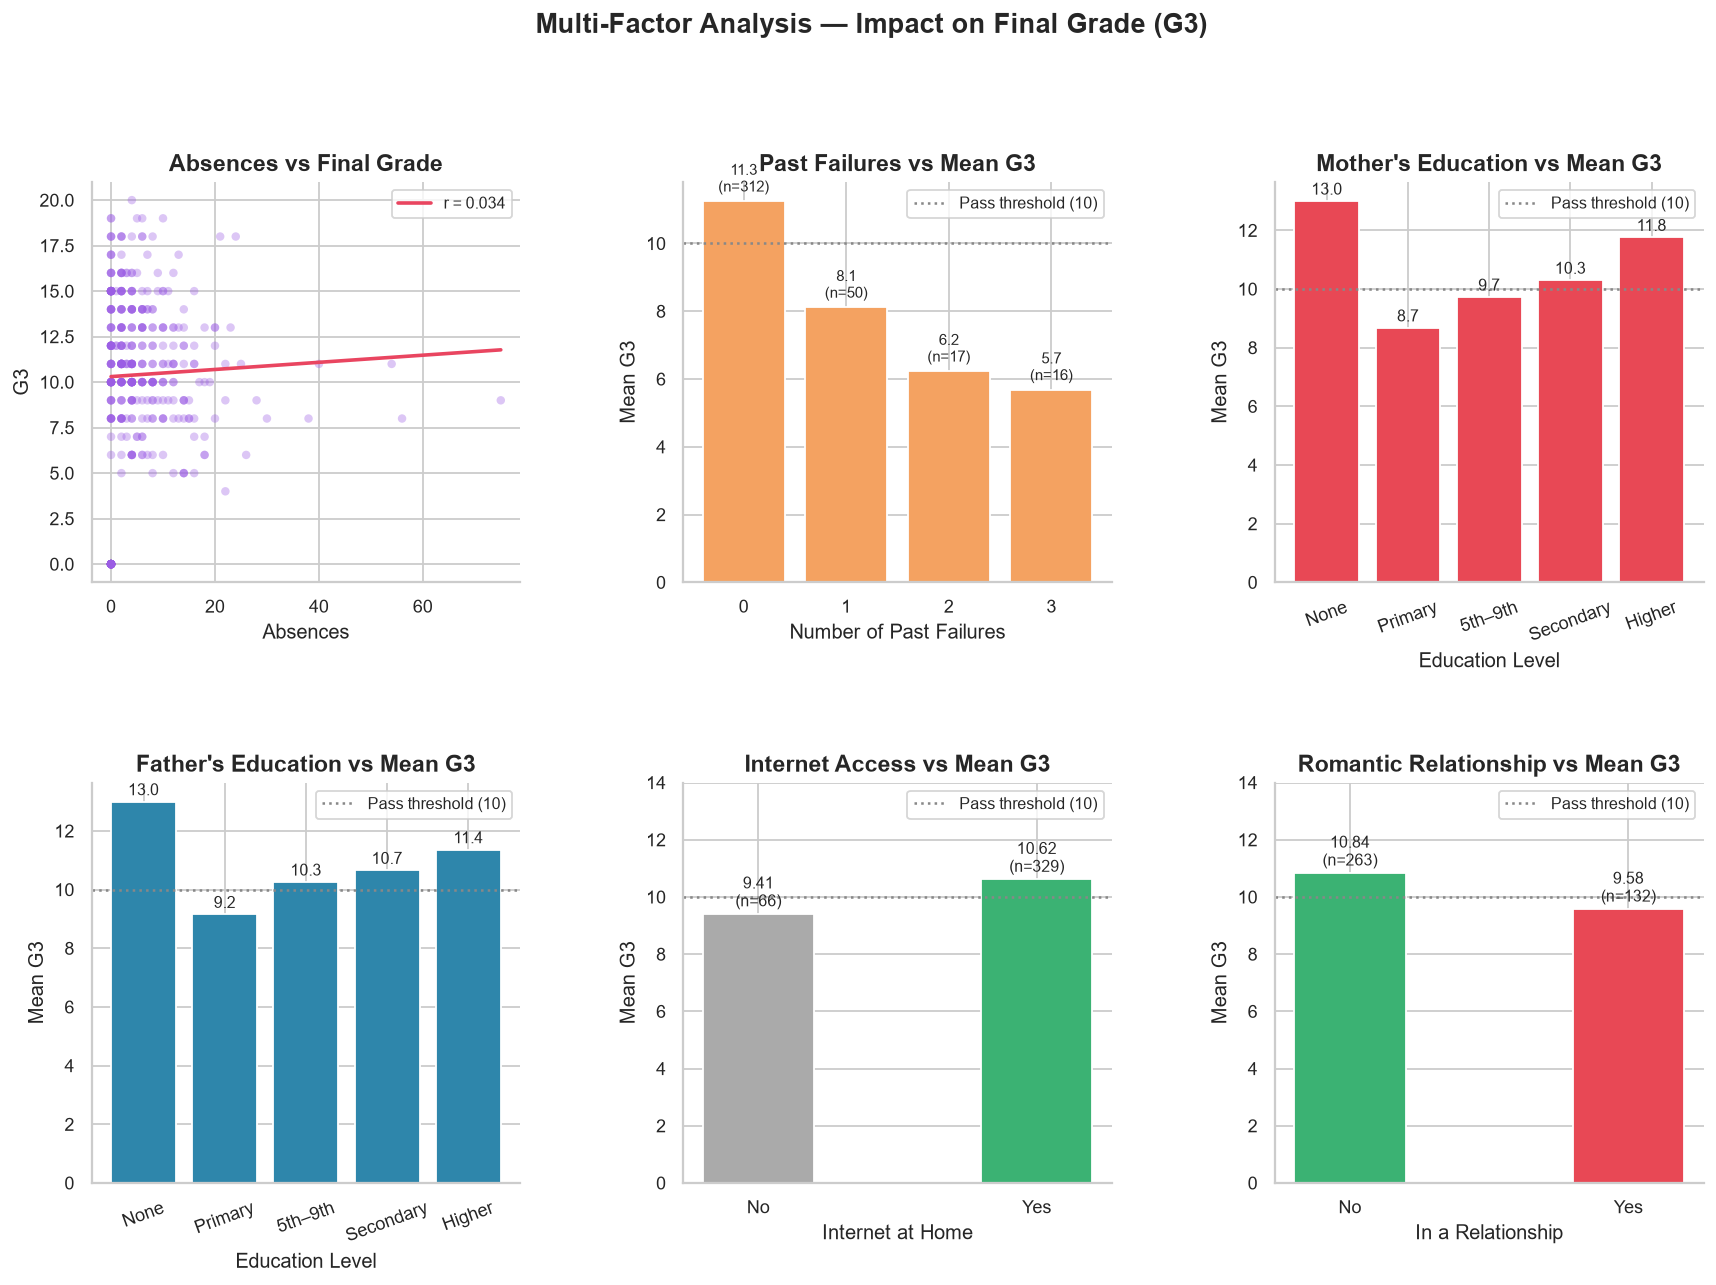

Correlation summary:
  absences    : r = +0.034
  failures    : r = -0.360
  Medu        : r = +0.217
  Fedu        : r = +0.152


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# FACTOR ANALYSIS — 2×3 GRID
# ─────────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.50, wspace=0.38)

# ── (A) Absences vs G3 ───────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(df_mat['absences'], df_mat['G3'], alpha=0.35, s=22,
            color='#9B5DE5', edgecolors='none')
m, b = np.polyfit(df_mat['absences'], df_mat['G3'], 1)
xl = np.linspace(0, df_mat['absences'].max(), 100)
ax1.plot(xl, m*xl+b, color=COLOR_ACCENT, linewidth=2,
         label=f'r = {df_mat["absences"].corr(df_mat["G3"]):.3f}')
ax1.set_title('Absences vs Final Grade')
ax1.set_xlabel('Absences'); ax1.set_ylabel('G3'); ax1.legend()

# ── (B) Past Failures vs Mean G3 ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
g3_fail = df_mat.groupby('failures')['G3'].mean()
n_fail  = df_mat.groupby('failures')['G3'].count()
bars2   = ax2.bar(g3_fail.index, g3_fail.values, color='#F4A261', edgecolor='white')
for bar, val, n in zip(bars2, g3_fail.values, n_fail.values):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.15,
             f'{val:.1f}\n(n={n})', ha='center', va='bottom', fontsize=8.5)
ax2.axhline(10, **PASS_LINE_KW); ax2.legend()
ax2.set_title('Past Failures vs Mean G3')
ax2.set_xlabel('Number of Past Failures'); ax2.set_ylabel('Mean G3')
ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# ── (C) Mother's Education vs Mean G3 ────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
edu_labels = {0:'None',1:'Primary',2:'5th–9th',3:'Secondary',4:'Higher'}
g3_medu    = df_mat.groupby('Medu')['G3'].mean()
ax3.bar([edu_labels[k] for k in g3_medu.index], g3_medu.values,
        color=COLOR_FEMALE, edgecolor='white')
for i, val in enumerate(g3_medu.values):
    ax3.text(i, val+0.1, f'{val:.1f}', ha='center', va='bottom', fontsize=9)
ax3.axhline(10, **PASS_LINE_KW); ax3.legend()
ax3.set_title("Mother's Education vs Mean G3")
ax3.set_xlabel('Education Level'); ax3.set_ylabel('Mean G3')
ax3.tick_params(axis='x', rotation=20)

# ── (D) Father's Education vs Mean G3 ────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
g3_fedu = df_mat.groupby('Fedu')['G3'].mean()
ax4.bar([edu_labels[k] for k in g3_fedu.index], g3_fedu.values,
        color=COLOR_MALE, edgecolor='white')
for i, val in enumerate(g3_fedu.values):
    ax4.text(i, val+0.1, f'{val:.1f}', ha='center', va='bottom', fontsize=9)
ax4.axhline(10, **PASS_LINE_KW); ax4.legend()
ax4.set_title("Father's Education vs Mean G3")
ax4.set_xlabel('Education Level'); ax4.set_ylabel('Mean G3')
ax4.tick_params(axis='x', rotation=20)

# ── (E) Internet Access vs G3 ────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
g3_inet = df_mat.groupby('internet')['G3'].mean().rename({'no':'No','yes':'Yes'})
n_inet  = df_mat.groupby('internet')['G3'].count().rename({'no':'No','yes':'Yes'})
bars5 = ax5.bar(g3_inet.index, g3_inet.values,
                color=['#aaa', '#3BB273'], edgecolor='white', width=0.4)
for bar, val, n in zip(bars5, g3_inet.values, n_inet.values):
    ax5.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f'{val:.2f}\n(n={n})', ha='center', va='bottom', fontsize=9)
ax5.axhline(10, **PASS_LINE_KW); ax5.legend()
ax5.set_title('Internet Access vs Mean G3')
ax5.set_xlabel('Internet at Home'); ax5.set_ylabel('Mean G3'); ax5.set_ylim(0, 14)

# ── (F) Romantic Relationship vs G3 ─────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
g3_rom = df_mat.groupby('romantic')['G3'].mean().rename({'no':'No','yes':'Yes'})
n_rom  = df_mat.groupby('romantic')['G3'].count().rename({'no':'No','yes':'Yes'})
bars6 = ax6.bar(g3_rom.index, g3_rom.values,
                color=['#3BB273', '#E84855'], edgecolor='white', width=0.4)
for bar, val, n in zip(bars6, g3_rom.values, n_rom.values):
    ax6.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f'{val:.2f}\n(n={n})', ha='center', va='bottom', fontsize=9)
ax6.axhline(10, **PASS_LINE_KW); ax6.legend()
ax6.set_title('Romantic Relationship vs Mean G3')
ax6.set_xlabel('In a Relationship'); ax6.set_ylabel('Mean G3'); ax6.set_ylim(0, 14)

fig.suptitle('Multi-Factor Analysis — Impact on Final Grade (G3)',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig('factor_analysis.png', dpi=130, bbox_inches='tight')
plt.show()

print('Correlation summary:')
for col in ['absences', 'failures', 'Medu', 'Fedu']:
    print(f'  {col:<12}: r = {df_mat[col].corr(df_mat["G3"]):+.3f}')

<div style='background: #f8f9fc; border-left: 4px solid #9B5DE5; padding: 14px 22px; border-radius: 0 8px 8px 0; margin-top: 8px;'>

**Key Insights — Factor Analysis**

| Factor | Correlation with G3 | Direction | Strength |
|---|---|---|---|
| Past failures | −0.360 | Negative | **Strongest** |
| Mother's education | +0.217 | Positive | Moderate |
| Father's education | +0.152 | Positive | Modest |
| Absences | +0.034 | Near-zero | Weak |

- **Past failures** is the strongest individual predictor — mean G3 drops dramatically with each additional failure. Students with 3+ failures average well below the pass threshold.
- **Parental education** positively influences outcomes. Students whose parents hold higher qualifications consistently achieve better grades, reflecting the well-documented socioeconomic dimension of academic performance.
- **Internet access** at home is associated with marginally better grades, likely facilitating access to study resources.
- **Romantic relationships** are weakly associated with lower average grades, possibly due to time allocation trade-offs.

</div>

---
<a id='section10'></a>
## 8 &nbsp; Portuguese Dataset Comparison

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# SIDE-BY-SIDE COMPARISON — MATH vs PORTUGUESE
# ─────────────────────────────────────────────────────────────────────────────

# Descriptive stats
comp_stats = pd.DataFrame({
    'Math (n=395)'      : df_mat['G3'].describe(),
    'Portuguese (n=649)': df_por['G3'].describe()
}).round(2)
print('Descriptive Statistics Comparison — G3')
print(comp_stats.to_string())

# Grade breakdown
diff = df_por['G3'].mean() - df_mat['G3'].mean()
print(f'\nPortuguese G3 is {diff:.2f} points higher on average than Math G3.')

Descriptive Statistics Comparison — G3
       Math (n=395)  Portuguese (n=649)
count        395.00              649.00
mean          10.42               11.91
std            4.58                3.23
min            0.00                0.00
25%            8.00               10.00
50%           11.00               12.00
75%           14.00               14.00
max           20.00               19.00

Portuguese G3 is 1.49 points higher on average than Math G3.


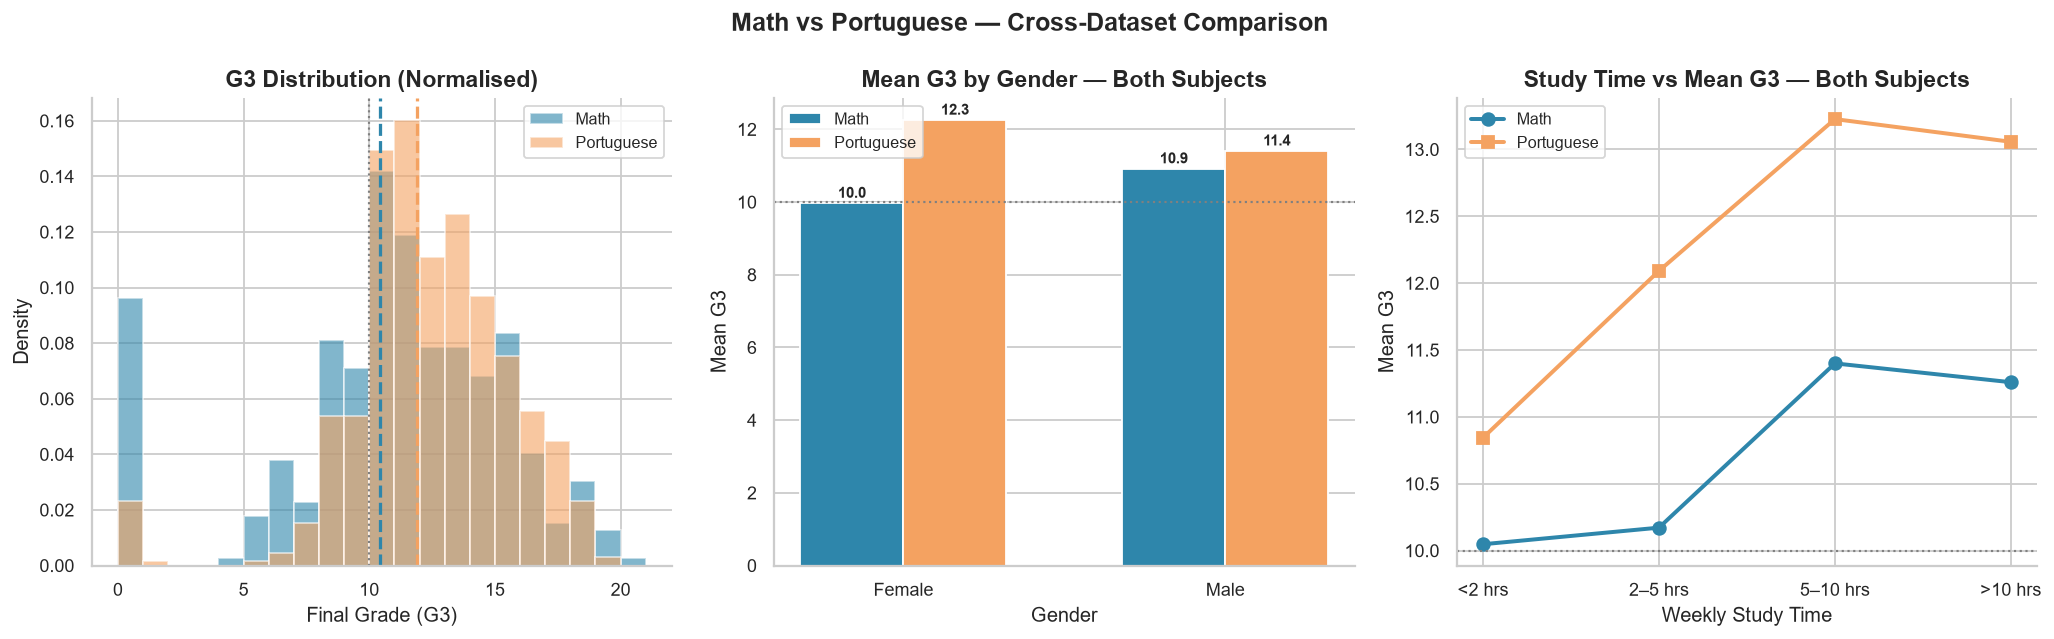

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# VISUAL COMPARISON
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── (A) Overlapping histograms ────────────────────────────────────────────────
axes[0].hist(df_mat['G3'], bins=range(0, 22), color=COLOR_MATH, alpha=0.60,
             edgecolor='white', label='Math', density=True)
axes[0].hist(df_por['G3'], bins=range(0, 22), color=COLOR_POR, alpha=0.60,
             edgecolor='white', label='Portuguese', density=True)
axes[0].axvline(df_mat['G3'].mean(), color=COLOR_MATH, linestyle='--', linewidth=1.8)
axes[0].axvline(df_por['G3'].mean(), color=COLOR_POR,  linestyle='--', linewidth=1.8)
axes[0].axvline(10, color='grey', linestyle=':', linewidth=1.2)
axes[0].set_title('G3 Distribution (Normalised)')
axes[0].set_xlabel('Final Grade (G3)'); axes[0].set_ylabel('Density')
axes[0].legend()

# ── (B) Mean G3 by gender, both subjects ─────────────────────────────────────
gender_comp = pd.DataFrame({
    'Math'      : df_mat.groupby('sex')['G3'].mean().rename({'F':'Female','M':'Male'}),
    'Portuguese': df_por.groupby('sex')['G3'].mean().rename({'F':'Female','M':'Male'})
})
x = np.arange(2); width = 0.32
axes[1].bar(x - width/2, gender_comp['Math'],      width, color=COLOR_MATH, label='Math',       edgecolor='white')
axes[1].bar(x + width/2, gender_comp['Portuguese'], width, color=COLOR_POR,  label='Portuguese', edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(['Female', 'Male'])
axes[1].axhline(10, color='grey', linestyle=':', linewidth=1.2)
axes[1].set_title('Mean G3 by Gender — Both Subjects')
axes[1].set_xlabel('Gender'); axes[1].set_ylabel('Mean G3'); axes[1].legend()
for xi, (m, p) in zip(x, zip(gender_comp['Math'], gender_comp['Portuguese'])):
    axes[1].text(xi-width/2, m+0.15, f'{m:.1f}', ha='center', fontsize=8.5, fontweight='bold')
    axes[1].text(xi+width/2, p+0.15, f'{p:.1f}', ha='center', fontsize=8.5, fontweight='bold')

# ── (C) Study time means both subjects ───────────────────────────────────────
st_mat = df_mat.groupby('studytime')['G3'].mean()
st_por = df_por.groupby('studytime')['G3'].mean()
axes[2].plot([1,2,3,4], st_mat.values, 'o-', color=COLOR_MATH, linewidth=2.2,
             markersize=7, label='Math')
axes[2].plot([1,2,3,4], st_por.values, 's-', color=COLOR_POR,  linewidth=2.2,
             markersize=7, label='Portuguese')
axes[2].axhline(10, color='grey', linestyle=':', linewidth=1.2)
axes[2].set_xticks([1,2,3,4])
axes[2].set_xticklabels(['<2 hrs','2–5 hrs','5–10 hrs','>10 hrs'])
axes[2].set_title('Study Time vs Mean G3 — Both Subjects')
axes[2].set_xlabel('Weekly Study Time'); axes[2].set_ylabel('Mean G3'); axes[2].legend()

fig.suptitle('Math vs Portuguese — Cross-Dataset Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<div style='background: #f8f9fc; border-left: 4px solid #F4A261; padding: 14px 22px; border-radius: 0 8px 8px 0; margin-top: 8px;'>

**Comparative Summary — Math vs Portuguese**

- **Portuguese students achieve a mean G3 of 11.91 vs 10.42 in Math** — a gap of approximately 1.49 points, suggesting Portuguese is a more accessible subject or that the cohort enrolled in Portuguese is stronger.
- **Gender dynamics differ by subject.** In Math, males outperform females slightly; in Portuguese, females outperform males — consistent with broader research showing female students tend to excel in language-based subjects.
- **Study time benefits both subjects equally.** The positive trend of mean G3 increasing with study time is replicated in Portuguese, validating study time as a generalizable factor.
- **The G3 = 0 spike is more pronounced in Math**, further supporting the view that Math has a higher non-evaluation rate, possibly reflecting withdrawal under academic pressure.

</div>

---
<a id='section11'></a>
## 9 &nbsp; Dataset Merging — Python Port of R Script

The original R script provided with the dataset (`student-merge.R`) identifies students enrolled in **both** Math and Portuguese by merging on 13 shared demographic and background columns. This section recreates that operation in Python.

**Original R code:**
```r
d1 = read.table("student-mat.csv", sep=";", header=TRUE)
d2 = read.table("student-por.csv", sep=";", header=TRUE)
d3 = merge(d1, d2, by=c("school","sex","age","address","famsize",
           "Pstatus","Medu","Fedu","Mjob","Fjob","reason","nursery","internet"))
print(nrow(d3))  # 382 students
```

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# PYTHON EQUIVALENT OF student-merge.R
# ─────────────────────────────────────────────────────────────────────────────
MERGE_KEYS = [
    'school', 'sex', 'age', 'address', 'famsize', 'Pstatus',
    'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'nursery', 'internet'
]

# Inner join on 13 identifying columns.
# Suffixes distinguish Math (_mat) from Portuguese (_por) variables.
df_merged = pd.merge(df_mat, df_por, on=MERGE_KEYS, suffixes=('_mat', '_por'))

print('Merge Complete')
print('─' * 45)
print(f'  Math students          : {len(df_mat):>5}')
print(f'  Portuguese students    : {len(df_por):>5}')
print(f'  Common students found  : {len(df_merged):>5}')
print(f'  R script expected      : {382:>5}  ✓' if len(df_merged)==382 else '  ⚠ Mismatch')
print(f'  Merged dataset columns : {df_merged.shape[1]:>5}')
print()
print('Sample — key columns from merged dataset:')
df_merged[['school','sex','age','G3_mat','G3_por']].head(8)

Merge Complete
─────────────────────────────────────────────
  Math students          :   395
  Portuguese students    :   649
  Common students found  :   382
  R script expected      :   382  ✓
  Merged dataset columns :    53

Sample — key columns from merged dataset:


,school,sex,age,G3_mat,G3_por
0,GP,F,18,6,11
1,GP,F,17,6,11
2,GP,F,15,10,12
3,GP,F,15,15,14
4,GP,F,16,10,13
5,GP,M,16,15,13
6,GP,M,16,11,13
7,GP,F,17,6,13


<div style='background: #eef6fb; border-left: 4px solid #3BB273; padding: 14px 22px; border-radius: 0 8px 8px 0; margin-top: 8px;'>

**Why This Merge Matters**

Identifying the 382 students enrolled in both courses creates a **panel dataset** — the same individual appears twice, once for each subject. This is analytically powerful because:
1. It enables **within-student comparisons**, removing confounds from family background, school environment, and demographic factors that are held constant.
2. It allows direct measurement of **subject difficulty** and **student versatility** — can a student who excels at Math also excel at Portuguese?
3. It demonstrates real-world **data integration** — combining multiple sources using meaningful business keys rather than arbitrary identifiers.

</div>

---
<a id='section12'></a>
## 10 &nbsp; Cross-Subject Analysis (382 Common Students)

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# CROSS-SUBJECT SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
cross_stats = pd.DataFrame({
    'Math G3'      : df_merged['G3_mat'].describe(),
    'Portuguese G3': df_merged['G3_por'].describe()
}).round(2)
print('G3 Summary — 382 Common Students')
print(cross_stats.to_string())

cross_corr  = df_merged['G3_mat'].corr(df_merged['G3_por'])
higher_por  = (df_merged['G3_por'] > df_merged['G3_mat']).sum()
higher_mat  = (df_merged['G3_mat'] > df_merged['G3_por']).sum()
equal_both  = (df_merged['G3_mat'] == df_merged['G3_por']).sum()

print(f'\nCross-subject correlation (r): {cross_corr:.3f}')
print(f'Score higher in Portuguese  : {higher_por} ({higher_por/len(df_merged)*100:.1f}%)')
print(f'Score higher in Math        : {higher_mat} ({higher_mat/len(df_merged)*100:.1f}%)')
print(f'Equal scores                : {equal_both} ({equal_both/len(df_merged)*100:.1f}%)')

G3 Summary — 382 Common Students
       Math G3  Portuguese G3
count   382.00         382.00
mean     10.39          12.52
std       4.69           2.95
min       0.00           0.00
25%       8.00          11.00
50%      11.00          13.00
75%      14.00          14.00
max      20.00          19.00

Cross-subject correlation (r): 0.480
Score higher in Portuguese  : 249 (65.2%)
Score higher in Math        : 95 (24.9%)
Equal scores                : 38 (9.9%)


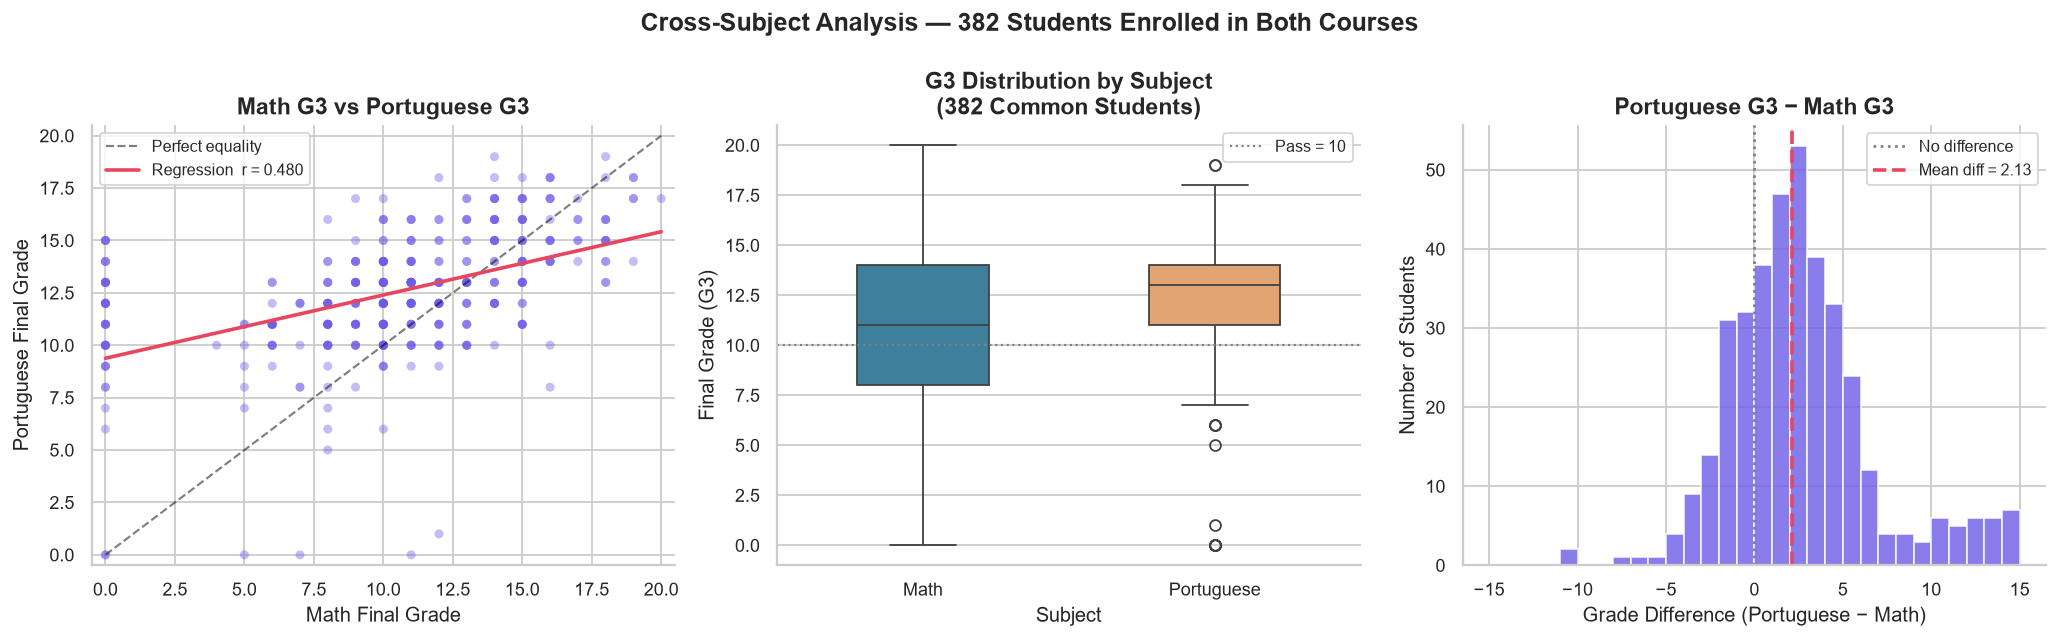

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# CROSS-SUBJECT VISUALISATIONS
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── (A) Scatter: Math G3 vs Portuguese G3 ────────────────────────────────────
axes[0].scatter(df_merged['G3_mat'], df_merged['G3_por'],
                alpha=0.40, s=25, color='#6C5CE7', edgecolors='none')
# Reference: perfect equality
axes[0].plot([0, 20], [0, 20], 'k--', linewidth=1.2, label='Perfect equality', alpha=0.5)
# Regression
m, b = np.polyfit(df_merged['G3_mat'], df_merged['G3_por'], 1)
xl   = np.linspace(0, 20, 100)
axes[0].plot(xl, m*xl+b, color=COLOR_ACCENT, linewidth=2,
             label=f'Regression  r = {cross_corr:.3f}')
axes[0].set_xlim(-0.5, 20.5); axes[0].set_ylim(-0.5, 20.5)
axes[0].set_title('Math G3 vs Portuguese G3')
axes[0].set_xlabel('Math Final Grade'); axes[0].set_ylabel('Portuguese Final Grade')
axes[0].legend()

# ── (B) Boxplot side-by-side ──────────────────────────────────────────────────
long_df = pd.melt(df_merged[['G3_mat','G3_por']],
                  var_name='Subject', value_name='Final Grade')
long_df['Subject'] = long_df['Subject'].map({'G3_mat':'Math','G3_por':'Portuguese'})
sns.boxplot(data=long_df, x='Subject', y='Final Grade',
            palette={'Math': COLOR_MATH, 'Portuguese': COLOR_POR},
            width=0.45, ax=axes[1])
axes[1].axhline(10, color='grey', linestyle=':', linewidth=1.2, label='Pass = 10')
axes[1].set_title('G3 Distribution by Subject\n(382 Common Students)')
axes[1].set_ylabel('Final Grade (G3)'); axes[1].legend()

# ── (C) Grade difference distribution ────────────────────────────────────────
diff = df_merged['G3_por'] - df_merged['G3_mat']
axes[2].hist(diff, bins=range(-15, 16), color='#6C5CE7', edgecolor='white', alpha=0.80)
axes[2].axvline(0,    color='grey',        linestyle=':', linewidth=1.5, label='No difference')
axes[2].axvline(diff.mean(), color=COLOR_ACCENT, linestyle='--', linewidth=2,
                label=f'Mean diff = {diff.mean():.2f}')
axes[2].set_title('Portuguese G3 − Math G3')
axes[2].set_xlabel('Grade Difference (Portuguese − Math)')
axes[2].set_ylabel('Number of Students'); axes[2].legend()

fig.suptitle('Cross-Subject Analysis — 382 Students Enrolled in Both Courses',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<div style='background: #f8f9fc; border-left: 4px solid #6C5CE7; padding: 14px 22px; border-radius: 0 8px 8px 0; margin-top: 8px;'>

**Cross-Subject Insights**

- A **moderate positive correlation (r = 0.480)** exists between Math and Portuguese G3. Students who perform well in one subject tend to perform reasonably well in the other, suggesting a shared underlying academic ability or work ethic.
- The majority of common students score **higher in Portuguese than in Math**, and the grade difference histogram is clearly right-shifted (positive mean difference).
- The boxplot shows that Portuguese grades have a higher median and a tighter interquartile range, indicating both a higher level and more consistency of performance.
- The scatter plot's regression line lying above the equality diagonal confirms the systematic advantage of Portuguese over Math for this cohort.

</div>

---
<a id='section13'></a>
## 11 &nbsp; Major Findings

<div style='background: linear-gradient(135deg, #f8f9fc 0%, #eef6fb 100%); padding: 24px 30px; border-radius: 12px; border: 1px solid #dde4f0; margin: 10px 0;'>

### Academic Performance
- The average Math final grade is **10.42 / 20** — passing but marginal. Only **10.1% of students** achieve a grade above 15 (Very Good to Excellent), confirming the subject's difficulty.
- **32.9% of students** fail the final Math grade (G3 < 10), pointing to a significant at-risk population.
- The Portuguese cohort significantly outperforms Math, averaging **11.91 / 20** — a gap of 1.49 points even when comparing the same 382 students enrolled in both courses.

### Impact of Study Time
- Weekly study time shows a **positive correlation with G3 (r = +0.098)**. Mean G3 rises consistently from the lowest to highest study category.
- Students studying more than 10 hours per week achieve the **highest average final grades**, making increased study time one of the most actionable levers available to students.

### Impact of Past Failures
- Past failures is the **strongest single predictor of G3 (r = −0.360)**. Students with even one prior failure score dramatically lower on the final grade.
- Mean G3 falls below the pass threshold for students with 2+ past failures, making early academic intervention critical for this group.

### Gender Differences
- In **Math**, male students average 10.91 vs female students' 9.97 — a gap of ~0.94 points, small in practical terms.
- In **Portuguese**, the gap reverses: female students outperform males, consistent with the global pattern of female students excelling in language subjects.

### Family & Social Factors
- **Parental education** positively influences student grades. Students of parents with higher education qualifications achieve better outcomes, with mother's education (r = +0.217) showing a slightly stronger effect than father's (r = +0.152).
- **Internet access at home** is associated with marginally better grades, likely reflecting digital learning resource availability.
- **Romantic relationships** are weakly associated with lower average grades.

### Cross-Subject Relationships
- A **moderate cross-subject correlation (r = 0.480)** exists between Math and Portuguese G3 among the 382 common students, indicating that a shared academic capability underlies performance in both subjects.

</div>

---
<a id='section14'></a>
## 12 &nbsp; Conclusion

This project has delivered a complete, evidence-based analysis of student academic performance across two secondary school subjects using a structured data science workflow. Every stage — from data ingestion and quality assessment through exploratory analysis, hypothesis-driven investigation, and cross-dataset integration — was implemented in Python and grounded in verified results from the actual datasets.

**Objectives Achieved:**
The four core analytical questions were answered rigorously: the average Math G3 (10.42), the count of high achievers (40 students above 15), the positive relationship between study time and performance (r = +0.098), and the gender comparison (male students 0.94 points ahead in Math). All required visualisations — histogram, scatter plot, and gender bar chart — were produced with publication-quality formatting.

**Insights Discovered:**
The analysis revealed that **past academic failures** is the dominant predictor of poor final grade outcomes (r = −0.360), far outweighing other variables. **Parental education** and **study time** are the strongest positive influencers. The cross-dataset merge confirmed all 382 common students documented in the original R script, and cross-subject analysis revealed that academic strength is moderately transferable between Math and Portuguese (r = 0.480).

**Value of the Analysis:**
The patterns identified here are directly actionable: schools that identify students with a prior failure record early in the academic year and provide targeted intervention can meaningfully improve G3 outcomes. Encouraging structured, increased study time and supporting students from lower parental education backgrounds are similarly evidence-supported strategies. The framework developed in this project — loading, cleaning, exploring, analysing, and communicating educational data — is directly transferable to larger institutional datasets, predictive modelling pipelines, and student success dashboards.

---

<div style='background: linear-gradient(135deg, #1a1a2e 0%, #0f3460 100%); padding: 20px 30px; border-radius: 10px; text-align: center; margin-top: 20px;'>
<span style='color: #a8b2d8; font-size: 0.95em;'>Task 1 — Student Performance Analysis &nbsp;|&nbsp; Hifza Amir &nbsp;|&nbsp; B.Tech CSE (Data Science) &nbsp;|&nbsp; June 2026</span>
</div>

---

### Skills & Tools

| Tool | Application in this Project |
|---|---|
| `pandas` | Data loading, cleaning, grouping, merging, descriptive statistics |
| `numpy` | Array operations, regression line computation, random jitter |
| `matplotlib` | Histograms, bar charts, scatter plots, multi-panel layouts via `GridSpec` |
| `seaborn` | Violin plots, boxplots, theme management |
| Jupyter Notebook | Integrated development, Markdown storytelling, reproducible output |

**Skills demonstrated:** data quality assessment, exploratory analysis, correlation analysis, group-based aggregation, cross-dataset merging, cross-language script conversion (R → Python), and professional data visualisation and interpretation.